# Titanic Survival Analysis
### Tools: Python, Pandas, Matplotlib, Seaborn
### Dataset: 891 passengers | Titanic (1912)

An exploratory analysis of Titanic passenger survival data, 
investigating how gender, class, age, and family size 
influenced survival chances.

---

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("Ready to visualize! 🔥")
titan = pd.read_csv("train.csv.xls", index_col=0)
titan.head()
titan.info()
titan.describe()

Ready to visualize! 🔥
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    str    
 10  Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 76.7 KB


,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


##  Overall Survival Rate

Only **38.38%** of passengers survived the Titanic disaster.  
Out of 891 passengers, 342 survived and 549 did not.

This sets the baseline — most passengers did not survive, 
making it important to understand which factors influenced 
who did.

In [75]:
# What % of passengers survived overall?
suervived_percentage = (titan['Survived'].sum() / len(titan)) * 100
print('The percentages of passengers survived overall is',suervived_percentage.round(2))

The percentages of passengers survived overall is 38.38


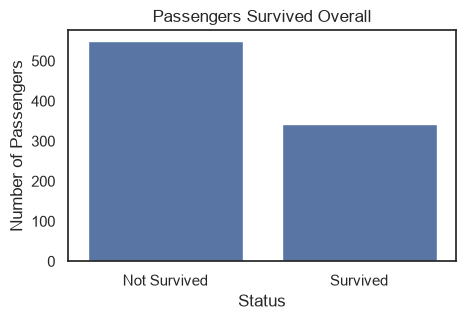

In [76]:
# count survived vs not survived
survival_counts = titan['Survived'].value_counts()

sns.set_theme(style='white')
plt.figure(figsize=(5, 3))
sns.barplot(x=['Not Survived', 'Survived'], y=survival_counts.values)
plt.title('Passengers Survived Overall')
plt.xlabel('Status')
plt.ylabel('Number of Passengers')
plt.show()

##  Survival Rate by Gender

Gender was the strongest predictor of survival.  
- **Female survival rate: ~74%**
- **Male survival rate: ~19%**

The "women and children first" evacuation policy 
was clearly enforced, giving female passengers 
a dramatically higher chance of survival.

In [77]:
# Did gender affect survival rate? 
survival_by_sex = titan.groupby('Sex').Survived.count()
survival_rates = titan.groupby('Sex').Survived.mean()*100
print(survival_by_sex)
print(survival_rates)

Sex
female    314
male      577
Name: Survived, dtype: int64
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


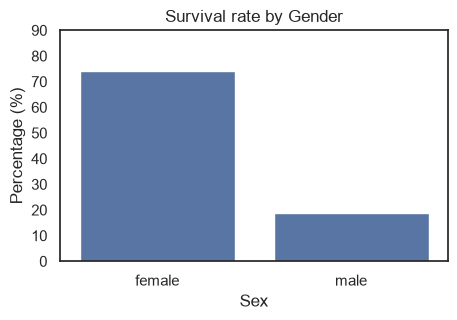

In [78]:
sns.set_theme(style='white')
plt.figure(figsize=(5, 3))
sns.barplot(x=survival_rates.index, y=survival_rates.values)
plt.title('Survival rate by Gender')
plt.xlabel('Sex')
plt.ylabel('Percentage (%)')
plt.yticks(range(0,100,10))
plt.show()

##  Survival Rate by Passenger Class

Passenger class had a significant impact on survival:
- **First Class: ~62%** survival rate
- **Second Class: ~47%** survival rate  
- **Third Class: ~24%** survival rate

Wealthier passengers had better access to lifeboats, 
likely due to cabin location (closer to the deck) 
and social privilege during evacuation.

In [79]:
# Did passenger class (Pclass) affect survival?
survival_by_class = titan.groupby('Pclass').Survived.count()
survival_rates_by_class = titan.groupby('Pclass').Survived.mean()*100
print(survival_by_class)
print(survival_rates_by_class.round(2))

Pclass
1    216
2    184
3    491
Name: Survived, dtype: int64
Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64


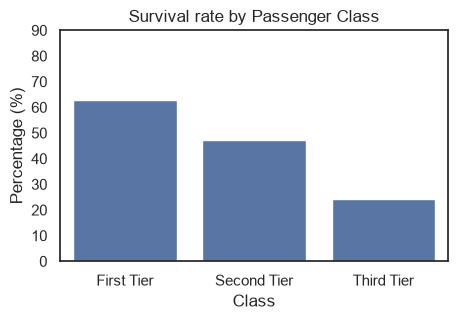

In [80]:
sns.set_theme(style='white')
plt.figure(figsize=(5, 3))
sns.barplot(x=survival_rates_by_class.index, y=survival_rates_by_class.values)
plt.title('Survival rate by Passenger Class')
plt.xlabel('Class')
plt.ylabel('Percentage (%)')
plt.yticks(range(0,100,10))
plt.xticks([0,1,2], ['First Tier', 'Second Tier','Third Tier']) #plt.xticks([positions], ['labels'])
plt.show()

##  Age Distribution: Survivors vs Non-Survivors

Average age of survivors: **28.3 years**  
Average age of non-survivors: **30.6 years**

The age gap is small — age alone was **not** a strong 
survival factor compared to gender and class.  
However, young children (0-10) show a slightly higher 
survival rate, consistent with the "children first" policy.

In [81]:
# What was the age distribution of survivors vs non-survivors?
survivors = titan.loc[titan['Survived'] == 1]
non_survivors = titan.loc[titan['Survived'] == 0]
print("Average age of survivors:", survivors['Age'].mean())
print("Average age of non-survivors:", non_survivors['Age'].mean())

Average age of survivors: 28.343689655172415
Average age of non-survivors: 30.62617924528302


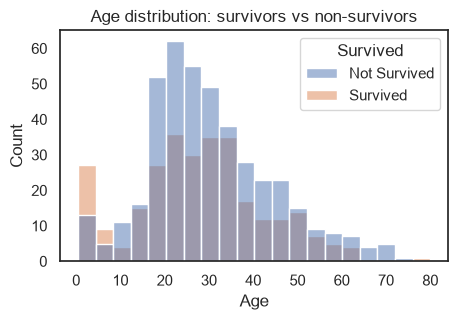

In [122]:
titan_copy = titan.copy()
titan_copy['Survived'] = titan_copy['Survived'].map({1: 'Survived',0: 'Not Survived'})

sns.set_theme(style='white')
plt.figure(figsize=(5, 3))
sns.histplot(data = titan_copy, x='Age',hue = 'Survived',bins=20,alpha = 0.5)
plt.title('Age distribution: survivors vs non-survivors')
plt.xticks(range(0,90,10))
plt.show()

##  Family Size vs Survival Rate

Family size revealed a clear pattern:
- **Alone: 30%** survival rate
- **Small Family (1-3): 58%** survival rate ← highest
- **Large Family (4+): 16%** survival rate ← lowest

There is a **sweet spot** — small families helped each other 
survive, while solo travelers had no support and large 
families struggled to coordinate evacuation together.

In [88]:
# Did having family aboard (SibSp + Parch) affect survival?
titan['Family_size'] = titan['SibSp'] + titan['Parch']
survival_by_family = titan.groupby('Family_size').Survived.count()
survival_rates_by_family = titan.groupby('Family_size').Survived.mean()
print(survival_by_family)
print(survival_rates_by_family.round(2))

def family_category(size):
    if size == 0:
        return "Alone"
    elif size <= 3:
        return "Small Family"
    else:
        return "Large Family"
    
titan['Family_group'] = titan['Family_size'].map(family_category)

survival_rates_by_FamGr = titan.groupby("Family_group").Survived.mean()*100
print(titan.groupby("Family_group").Survived.count().reset_index())
print(survival_rates_by_FamGr) #Survival Rate

Family_size
0     537
1     161
2     102
3      29
4      15
5      22
6      12
7       6
10      7
Name: Survived, dtype: int64
Family_size
0     0.30
1     0.55
2     0.58
3     0.72
4     0.20
5     0.14
6     0.33
7     0.00
10    0.00
Name: Survived, dtype: float64
   Family_group  Survived
0         Alone       537
1  Large Family        62
2  Small Family       292
Family_group
Alone           30.353818
Large Family    16.129032
Small Family    57.876712
Name: Survived, dtype: float64


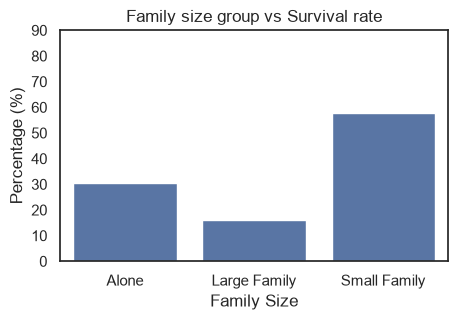

In [93]:
sns.set_theme(style='white')
plt.figure(figsize=(5, 3))
sns.barplot(x=survival_rates_by_FamGr.index, y= survival_rates_by_FamGr.values)
plt.title('Family size group vs Survival rate')
plt.xlabel('Family Size')
plt.ylabel('Percentage (%)')
plt.yticks(range(0,100,10))
plt.show()

##  Survival Rate by Gender AND Class

Combining gender and class reveals the most powerful insight:

| | First Class | Second Class | Third Class |
|---|---|---|---|
| **Female** | ~97% | ~92% | ~50% |
| **Male** | ~37% | ~16% | ~13% |

**Key finding:** Even Third Class females (~50%) survived 
at higher rates than First Class males (~37%).  
Gender completely overrode social class as a survival factor — 
being female mattered more than being wealthy.

In [125]:
survival_by_gen_class = titan.groupby(['Sex','Pclass'])['Survived'].mean().reset_index()
survival_by_gen_class['Survived'] = survival_by_gen_class['Survived'] * 100
print(survival_by_gen_class)

      Sex  Pclass   Survived
0  female       1  96.808511
1  female       2  92.105263
2  female       3  50.000000
3    male       1  36.885246
4    male       2  15.740741
5    male       3  13.544669


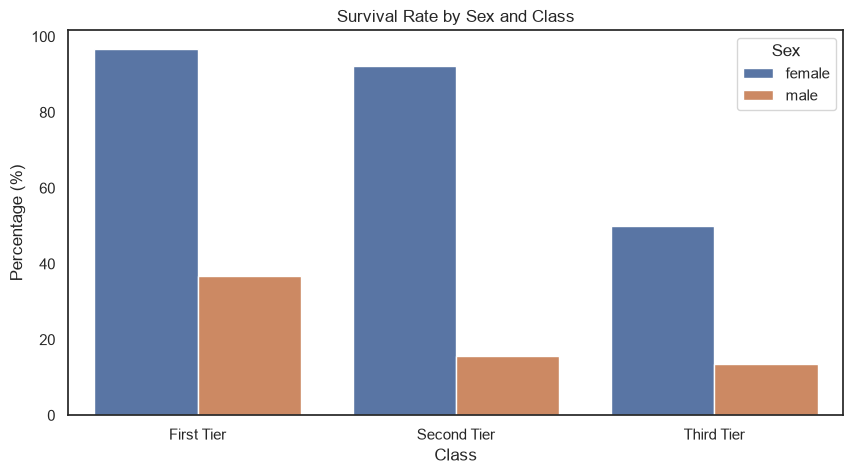

In [124]:
sns.set_theme(style='white')
plt.figure(figsize=(10, 5))
sns.barplot(data= survival_by_gen_class, x='Pclass', y='Survived', hue='Sex')
plt.title('Survival Rate by Sex and Class')
plt.xlabel('Class')
plt.ylabel('Percentage (%)')
plt.xticks([0,1,2], ['First Tier', 'Second Tier','Third Tier']) #plt.xticks([positions], ['labels'])
plt.show()